In [ ]:
import pandas as pd

train = pd.read_csv('train-2.csv')
test = pd.read_csv('test-2.csv')

print("TRAIN HEAD:")
print(train.head())

print("\nTEST HEAD:")
print(test.head())

print("\nTRAIN SHAPE:", train.shape)
print("TEST SHAPE:", test.shape)

print("\nCOLUMNS:")
print(train.columns)

TRAIN HEAD:
         date league  season  country                 home_team  \
0  2011-08-13     D1    2012  germany            TSG Hoffenheim   
1  2011-08-13     F1    2012   france                St Etienne   
2  2011-08-13     D1    2012  germany                  Nurnberg   
3  2011-08-13     D1    2012  germany  Borussia Monchengladbach   
4  2011-08-13     F1    2012   france              Valenciennes   

           away_team  match_result  home__is_shot_on_target_sum_avg  \
0  Borussia Dortmund           1.0                              5.0   
1  AS Nancy Lorraine           1.0                              2.0   
2        Hannover 96          -1.0                              7.0   
3      VfB Stuttgart           0.0                              3.0   
4              Brest           0.0                              6.0   

   home__Shooting accuracy_avg  home__is_goal_sum_avg  ...  \
0                     0.625000                    1.0  ...   
1                     0.250000    

In [ ]:
y_train = train['match_result']
y_test = test['match_result']

drop_cols = ['date', 'league', 'country', 'home_team', 'away_team', 'match_result']

X_train = train.drop(columns=drop_cols)
X_test = test.drop(columns=drop_cols)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nSample features:")
print(X_train.head())

X_train shape: (6231, 25)
X_test shape: (2748, 25)

Sample features:
   season  home__is_shot_on_target_sum_avg  home__Shooting accuracy_avg  \
0    2012                              5.0                     0.625000   
1    2012                              2.0                     0.250000   
2    2012                              7.0                     0.636364   
3    2012                              3.0                     0.750000   
4    2012                              6.0                     0.666667   

   home__is_goal_sum_avg  home__is_inside_box_sum_avg  home__CROSS_sum_avg  \
0                    1.0                          4.0                  3.0   
1                    2.0                          7.0                  3.0   
2                    1.0                          6.0                  1.0   
3                    1.0                          2.0                  0.0   
4                    0.0                          6.0                  5.0   

   home__PA

# RANDOM FOREST MODEL

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Model trained and predictions done.")

Model trained and predictions done.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.487627365356623

Confusion Matrix:
 [[320  51 410]
 [184  67 446]
 [236  81 953]]

Classification Report:

              precision    recall  f1-score   support

        -1.0       0.43      0.41      0.42       781
         0.0       0.34      0.10      0.15       697
         1.0       0.53      0.75      0.62      1270

    accuracy                           0.49      2748
   macro avg       0.43      0.42      0.40      2748
weighted avg       0.45      0.49      0.44      2748



# Confusion Matrix Plot

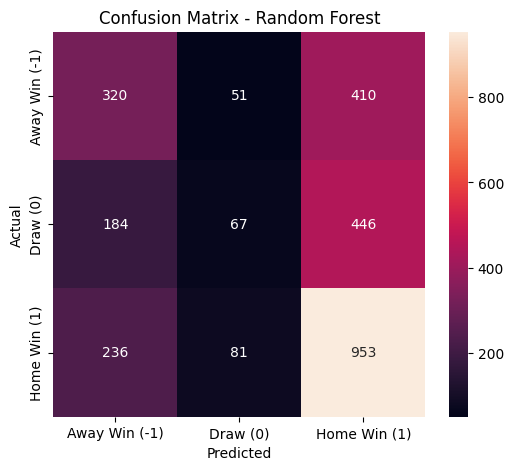

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = [-1.0, 0.0, 1.0]
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Away Win (-1)', 'Draw (0)', 'Home Win (1)'],
    yticklabels=['Away Win (-1)', 'Draw (0)', 'Home Win (1)']
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd

importances = rf.feature_importances_

feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

top_features = feat_imp.sort_values(by='importance', ascending=False).head(10)

print(top_features)

                        feature  importance
2   home__Shooting accuracy_avg    0.056403
10  away__Shooting accuracy_avg    0.055300
19   shooting_accuracy_diff_avg    0.054742
20          inside_box_diff_avg    0.052873
22         pass_assist_diff_avg    0.049500
18      shot_on_target_diff_avg    0.048527
6     home__PASS_ASSIST_sum_avg    0.045955
12  away__is_inside_box_sum_avg    0.045933
14    away__PASS_ASSIST_sum_avg    0.044592
4   home__is_inside_box_sum_avg    0.044061


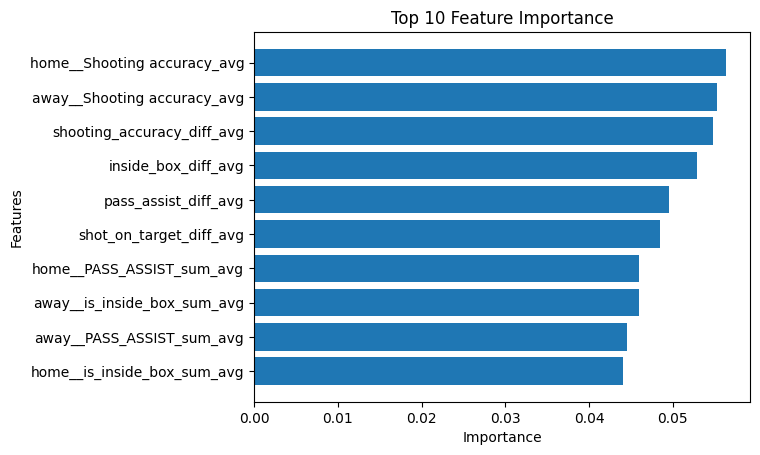

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()
plt.show()

# Logistic Regression

In [ ]:
import time
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

start_time = time.time()

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

end_time = time.time()
lr_runtime = end_time - start_time

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_cm = confusion_matrix(y_test, y_pred_lr, labels=[-1.0, 0.0, 1.0])

print("Logistic Regression Accuracy:", lr_acc)
print("Logistic Regression Runtime:", lr_runtime)

print("\nConfusion Matrix:\n", lr_cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.44614264919941776
Logistic Regression Runtime: 0.058878421783447266

Confusion Matrix:
 [[508  77 196]
 [349  94 254]
 [500 146 624]]

Classification Report:

              precision    recall  f1-score   support

        -1.0       0.37      0.65      0.48       781
         0.0       0.30      0.13      0.19       697
         1.0       0.58      0.49      0.53      1270

    accuracy                           0.45      2748
   macro avg       0.42      0.43      0.40      2748
weighted avg       0.45      0.45      0.43      2748



# Comparison Table

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_acc, acc],
    'Runtime (sec)': [lr_runtime, None],
})

print(comparison)

                 Model  Accuracy  Runtime (sec)
0  Logistic Regression  0.446143       0.058878
1        Random Forest  0.487627            NaN


In [ ]:
comparison.to_csv('model_comparison.csv', index=False)

# Random Forest Runtime + Tuning

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

start = time.time()

rf_tuned.fit(X_train, y_train)
y_pred_rf_tuned = rf_tuned.predict(X_test)

end = time.time()

rf_runtime = end - start
rf_acc = accuracy_score(y_test, y_pred_rf_tuned)

print("Tuned RF Accuracy:", rf_acc)
print("Tuned RF Runtime:", rf_runtime)

Tuned RF Accuracy: 0.4868995633187773
Tuned RF Runtime: 5.451898813247681


# Confusion Matrix for the Tuned Model

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

labels = [-1.0, 0.0, 1.0]
cm_tuned = confusion_matrix(y_test, y_pred_rf_tuned, labels=labels)

print(cm_tuned)
print(classification_report(y_test, y_pred_rf_tuned))

[[344  64 373]
 [210  60 427]
 [266  70 934]]
              precision    recall  f1-score   support

        -1.0       0.42      0.44      0.43       781
         0.0       0.31      0.09      0.13       697
         1.0       0.54      0.74      0.62      1270

    accuracy                           0.49      2748
   macro avg       0.42      0.42      0.40      2748
weighted avg       0.45      0.49      0.44      2748



Updated Comparison Table

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Tuned Random Forest'],
    'Accuracy': [lr_acc, acc, rf_acc],
    'Runtime (sec)': [lr_runtime, None, rf_runtime],
})

print(comparison)

                 Model  Accuracy  Runtime (sec)
0  Logistic Regression  0.446143       0.058878
1        Random Forest  0.487627            NaN
2  Tuned Random Forest  0.486900       5.451899
